In [1]:
%load_ext autoreload
%autoreload 2

import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from datetime import datetime
from order_fingers import TouchTracker
import matplotlib.pyplot as plt
import warnings
import itertools
from itertools import combinations
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

np.random.seed(42)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
DB_PATH = "./labeled_new.sqlite"

SENSOR_COLUMNS = [
    'button_pressed',
    'motor_angle',
    'touch_1_position', 'touch_1_pressure', 'touch_1_channel',
    'touch_2_position', 'touch_2_pressure', 'touch_2_channel',
    'touch_3_position', 'touch_3_pressure', 'touch_3_channel',
    'touch_4_position', 'touch_4_pressure', 'touch_4_channel',
    'touch_5_position', 'touch_5_pressure', 'touch_5_channel',
]
TIMESTAMP_COLUMN = 'timestamp_ms'
ID_COLUMNS = ['participant_id', 'session_task_id']
LABEL_COLUMN = 'parent_gesture'
TOUCH_MOVE_THRESHOLD = 0.01  # Radians

In [3]:
query = """
WITH start_end_indices AS (
    SELECT
        s.session_task_id,
        s.sensor_data_index AS start_index,
        MIN(e.sensor_data_index) AS next_end_index
    FROM preciseMarker s
    JOIN preciseMarker e 
        ON e.session_task_id = s.session_task_id
       AND e.sensor_data_index > s.sensor_data_index
    WHERE s.marker_type = 'start'
      AND e.marker_type = 'end'
    GROUP BY s.session_task_id, s.sensor_data_index
),
start_marker_timestamps AS (
    SELECT
        sensorData.session_task_id,
        session_task_row_index,
        preciseMarker.id AS group_id
    FROM sensorData
    JOIN preciseMarker
        ON sensorData.session_task_id = preciseMarker.session_task_id
       AND session_task_row_index = preciseMarker.sensor_data_index
    WHERE preciseMarker.marker_type = 'start'
),
session_first_start_last_end AS (
    SELECT
        sei.session_task_id,
        MIN(sei.start_index) AS first_start_index,
        MAX(sei.next_end_index) AS last_end_index
    FROM start_end_indices sei
    GROUP BY sei.session_task_id
),
gesture_samples AS (
    SELECT 
        sd.id,
        sd.session_task_id,
        sd.session_task_row_index,
        sd.timestamp,
        sd.timestamp_ms,
        sd.button_pressed,
        sd.motor_angle,
        sd.touch_1_position,
        sd.touch_1_pressure,
        sd.touch_1_channel,
        sd.touch_2_position,
        sd.touch_2_pressure,
        sd.touch_2_channel,
        sd.touch_3_position,
        sd.touch_3_pressure,
        sd.touch_3_channel,
        sd.touch_4_position,
        sd.touch_4_pressure,
        sd.touch_4_channel,
        sd.touch_5_position,
        sd.touch_5_pressure,
        sd.touch_5_channel,
        rt.title AS gesture,
        CASE WHEN rtParent.title != 'No Gesture' and smt.group_id is not null THEN rtParent.title ELSE 'No Gesture' END AS parent_gesture,
        s.participant_id,
        CASE WHEN rtParent.title != 'No Gesture' and smt.group_id is not null THEN 1 ELSE 0 END AS is_gesture,
        smt.group_id
    FROM sensorData sd
    left JOIN start_end_indices sei
      ON sd.session_task_id = sei.session_task_id
     AND sd.session_task_row_index BETWEEN sei.start_index AND sei.next_end_index
    left JOIN start_marker_timestamps smt
      ON smt.session_task_id = sei.session_task_id
     AND smt.session_task_row_index = sei.start_index
     JOIN session_first_start_last_end sfsle
      ON sd.session_task_id = sfsle.session_task_id
        AND sd.session_task_row_index BETWEEN sfsle.first_start_index AND sfsle.last_end_index
    LEFT JOIN sessionTask st
      ON sd.session_task_id = st.id
    LEFT JOIN session s
      ON st.session_id = s.id
    LEFT JOIN recordingTask rt
      ON st.recording_task_id = rt.id
    LEFT JOIN recordingTask rtParent
      ON rt.parent_id = rtParent.id
    WHERE rtParent.title != 'Szenarien'
)

-- Final combined dataset
SELECT * FROM gesture_samples
ORDER BY session_task_id, session_task_row_index;
"""

with sqlite3.connect(DB_PATH) as conn:
    df_raw = pd.read_sql_query(query, conn)

In [4]:
df_raw["gesture"] = df_raw["gesture"].astype("category")
df_raw["parent_gesture"] = df_raw["parent_gesture"].astype("category")

In [5]:
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw['time_diff'] = df_raw.groupby(['session_task_id', 'timestamp']).cumcount()
df_raw['recordings_per_second'] = df_raw.groupby(['session_task_id', 'timestamp'])['id'].transform('count')
df_raw['estimated_timestamp'] = df_raw['timestamp'] + pd.to_timedelta(df_raw['time_diff'] / df_raw['recordings_per_second'], unit='s')
df_raw = df_raw.drop(columns=['time_diff', 'recordings_per_second'])

df_raw["timestamp_ms"] = (df_raw["estimated_timestamp"].astype(np.int64) // 10**6).astype(np.int64)

In [6]:
is_null = df_raw["group_id"].isnull()
null_block_start = is_null & (~is_null.shift(1, fill_value=False))
block_ids = null_block_start.cumsum()
df_raw["group_id"] = df_raw["group_id"].fillna("no_gesture_block_" + block_ids.astype(str))

In [7]:
# Normalize the input data
# 1. Normalize all positions from [0, 2PI] to [0, 1]
for col in SENSOR_COLUMNS:
    if 'position' in col:
        df_raw[col] = df_raw[col] / (2 * np.pi)
# 2. Normalize pressures using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'pressure' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 3. Normalize channel values using min max scaling to [0, 1], per participant
for col in SENSOR_COLUMNS:
    if 'channel' in col:
        df_raw[col] = df_raw.groupby('participant_id')[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min())
        )
# 4. Normalize motor_angle using min max scaling to [0, 1], per participant
df_raw['motor_angle'] = df_raw.groupby('participant_id')['motor_angle'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)       

In [8]:
df_raw[LABEL_COLUMN].value_counts()

parent_gesture
No Gesture                        230485
Pinch Swipe                        12037
Tap and Hold                       11985
Spread Swipe                        9049
Single Swipe                        6072
Two-Finger Opposite Double Tap      3010
Two-Finger Double Tap               3001
Double Tap                          2784
Two-Finger Opposite Tap             1719
Two-Finger Tap                      1646
Single Tap                          1407
Name: count, dtype: int64

In [9]:
df_raw.groupby(["participant_id"]).size()

participant_id
5d52daf3-c962-4db6-a8f8-298a0bb01733    36375
6331fbd1-76bb-48d6-92a2-80a55a70d134    31589
696b4743-9d39-4fb1-8271-90e7d48652af    21096
6a1b56e6-47ce-43cb-96cb-713d055d8f6d    43728
707c3867-fe15-4b05-bf7b-fc5f3b501fb1    33659
754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0    39524
d3b39f0f-b799-4d69-b7a3-a663e5c7438f    35425
fdd02af8-c764-43ba-8247-c612f85568b4    41799
dtype: int64

In [10]:
# Sort after ID_COLUMNS and TIMESTAMP_COLUMN
df_raw = df_raw.sort_values(by=ID_COLUMNS + [TIMESTAMP_COLUMN]).reset_index(drop=True)

In [11]:
TOUCH_COLUMNS_BASE = ['position', 'pressure', 'channel']
MAX_TOUCHES = 5
TOUCH_PREFIXES = [f'touch_{i+1}' for i in range(MAX_TOUCHES)]

def process_and_stabilize_touches(df: pd.DataFrame):
    all_stabilized_rows = []
    active_ids_per_row = []
    
    tracker = TouchTracker() 
    tracker_group_id = None
    
    # id_to_slot_map: {touch_id: slot_index}
    id_to_slot_map = {} 
    # last_seen_in_row: {touch_id: index_of_last_appearance}
    last_seen_in_row = {} 

    for index, row in df.iterrows():
        current_group_id = row.get('session_task_id', None)
        
        if tracker_group_id != current_group_id:
            tracker.clear()
            id_to_slot_map = {}
            last_seen_in_row = {}
            tracker_group_id = current_group_id
        
        # 1. Extract raw touches
        new_touches = []
        for prefix in TOUCH_PREFIXES:
            pos = row[f'{prefix}_position']
            press = row[f'{prefix}_pressure']
            chan = row[f'{prefix}_channel']
            new_touches.append((pos, press, chan))
            
        # 2. Assign IDs via tracker
        matched_touches = tracker.assign_ids(new_touches)
        
        # 3. Handle Slot Mapping with Eviction Logic
        row_slots = [np.nan] * (MAX_TOUCHES * len(TOUCH_COLUMNS_BASE))
        current_row_ids = [t[0] for t in matched_touches]

        for touch in matched_touches:
            tid, touch_data = touch[0], touch[1:]
            last_seen_in_row[tid] = index # Track when we last saw this ID active

            if tid not in id_to_slot_map:
                existing_slots = set(id_to_slot_map.values())
                
                if len(existing_slots) < MAX_TOUCHES:
                    # Case A: Room available, find first empty slot
                    for s_idx in range(MAX_TOUCHES):
                        if s_idx not in existing_slots:
                            id_to_slot_map[tid] = s_idx
                            break
                else:
                    # Case B: Map is full. Find the ID in the map that 
                    # hasn't been seen for the longest time and steal its slot.
                    # This happens if persistence is holding a slot for a finger that isn't there.
                    oldest_tid = min(id_to_slot_map.keys(), key=lambda x: last_seen_in_row.get(x, -1))
                    stolen_slot = id_to_slot_map.pop(oldest_tid)
                    id_to_slot_map[tid] = stolen_slot
                    # Also clean up tracker if we are force-evicting from slot map
                    if oldest_tid in tracker.persistence_buffer:
                        del tracker.persistence_buffer[oldest_tid]
            
            slot = id_to_slot_map[tid]
            start_idx = slot * len(TOUCH_COLUMNS_BASE)
            row_slots[start_idx : start_idx + 3] = touch_data

        # 4. Standard Cleanup: Sync with Tracker's own expiration
        all_remembered_ids = set(tracker.active_touches.keys()) | set(tracker.persistence_buffer.keys())
        ids_to_forget = [tid for tid in id_to_slot_map if tid not in all_remembered_ids]
        for tid in ids_to_forget:
            id_to_slot_map.pop(tid, None)

        all_stabilized_rows.append(row_slots)
        active_ids_per_row.append(current_row_ids)

    # DataFrame creation...
    new_col_names = [f'{p}_{c}' for p in TOUCH_PREFIXES for c in TOUCH_COLUMNS_BASE]
    stabilized_df = pd.DataFrame(all_stabilized_rows, index=df.index, columns=new_col_names)
    stabilized_df['active_ids'] = active_ids_per_row
    return stabilized_df

In [12]:
# Stabilize dataframe, but only the first session_task_id for testing
stabilized_touch_data = process_and_stabilize_touches(df_raw.copy())
non_touch_cols = [c for c in df_raw.columns if not any(c.startswith(f'touch_{i+1}') for i in range(MAX_TOUCHES))]
final_df = df_raw[non_touch_cols].copy()

df_clean = final_df.join(stabilized_touch_data)

print("Stabilization Complete.")

Stabilization Complete.


In [13]:
# Set 0 for null values in position, pressure, channel columns for touches 2 to 5
for touch_num in range(1, 6):
    position_col = f'touch_{touch_num}_position'
    pressure_col = f'touch_{touch_num}_pressure'
    channel_col = f'touch_{touch_num}_channel'
    
    df_clean[position_col] = df_clean[position_col].fillna(0)
    df_clean[pressure_col] = df_clean[pressure_col].fillna(0)
    df_clean[channel_col] = df_clean[channel_col].fillna(0)
df_clean.isna().sum()

id                        0
session_task_id           0
session_task_row_index    0
timestamp                 0
timestamp_ms              0
button_pressed            0
motor_angle               0
gesture                   0
parent_gesture            0
participant_id            0
is_gesture                0
group_id                  0
estimated_timestamp       0
touch_1_position          0
touch_1_pressure          0
touch_1_channel           0
touch_2_position          0
touch_2_pressure          0
touch_2_channel           0
touch_3_position          0
touch_3_pressure          0
touch_3_channel           0
touch_4_position          0
touch_4_pressure          0
touch_4_channel           0
touch_5_position          0
touch_5_pressure          0
touch_5_channel           0
active_ids                0
dtype: int64

In [14]:
# Add new features to the dataframe, for improved modeling
def create_feature_df(df_clean, smoothing_window=5, long_smoothing_window=20):
    # Create empty feature dataframe
    feature_df = df_clean.copy()
    additional_features = []

    def add_feature(name, values):
        feature_df[name] = values
        additional_features.append(name)

    # Distances between each finger (including wrapping)
    def short_dist(a, b):
        return np.abs(np.arctan2(np.sin(a - b), np.cos(a - b)))
    
    # Instant Features
    pressure_cols = [f"touch_{i+1}_pressure" for i in range(5)]
    active_touches = (feature_df[pressure_cols] > 0)
    # add_feature("num_active_touches", active_touches.sum(axis=1))

    # Distances for each finger in the rolling window to each other finger
    for (i, j) in combinations(range(1, 6), 2):
        pos_i = feature_df[f'touch_{i}_position']
        pos_j = feature_df[f'touch_{j}_position']
        p_i = feature_df[f"touch_{i}_pressure"]
        p_j = feature_df[f"touch_{j}_pressure"]

        # distance only when both fingers are active; else 0 (or np.nan if you prefer)
        dist_col = f"dist_{i}_{j}"
        dist = short_dist(pos_i, pos_j)
        both_touching = (p_i > 0) & (p_j > 0)
        add_feature(dist_col, dist)
        # add_feature(f"{dist_col}_both_touching", both_touching.astype(int))

        # Calculate a flag if both fingers are active in the long smoothing window
        # long_both_touching = both_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f"{dist_col}_long_both_active", long_both_touching.astype(int))

        # Calculate a flag if both have moved
        # min_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_i = pos_i.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_i = (max_long_rolling_i - min_long_rolling_i) > TOUCH_MOVE_THRESHOLD
        # min_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).min()
        # max_long_rolling_j = pos_j.rolling(window=long_smoothing_window, min_periods=1).max()
        # has_moved_j = (max_long_rolling_j - min_long_rolling_j) > TOUCH_MOVE_THRESHOLD
        # both_moved = has_moved_i & has_moved_j
        # add_feature(f"{dist_col}_both_moved_longterm", both_moved.astype(int))

    # Smoothed Features
    for touch_num in range(1, 6):
        position_col = f'touch_{touch_num}_position'
        pressure_col = f'touch_{touch_num}_pressure'
        channel_col = f'touch_{touch_num}_channel'

        # velocity calculation
        pos_diff = feature_df[position_col].diff().fillna(0)
        time_diff = feature_df[TIMESTAMP_COLUMN].diff().fillna(1) / 1000.0  # convert ms to s
        velocity = pos_diff / time_diff
        # add_feature(f'touch_{touch_num}_position_velocity', velocity)

        # split to rotational position into x and y components for smoothing
        # add_feature(f'touch_{touch_num}_pos_x', np.cos(2 * np.pi * feature_df[position_col]))
        # add_feature(f'touch_{touch_num}_pos_y', np.sin(2 * np.pi * feature_df[position_col]))

        # Get the min and max distance to all other fingers
        other_positions = [f'touch_{i}_position' for i in range(1, 6) if i != touch_num]
        if other_positions:
            for other_pos_col in other_positions:
                dist_to_other = short_dist(feature_df[position_col], feature_df[other_pos_col])
                add_feature(f'touch_{touch_num}_dist_to_{other_pos_col}', dist_to_other)
        # else:
        #     add_feature(f'touch_{touch_num}_min_dist_to_others', pd.Series(0, index=feature_df.index))
        #     add_feature(f'touch_{touch_num}_max_dist_to_others', pd.Series(0, index=feature_df.index))    

        is_touching = (feature_df[pressure_col] > 0)
        # add_feature(f'touch_{touch_num}_is_active', is_touching.astype(int))
        is_active_smoothed = is_touching.rolling(window=smoothing_window, min_periods=1).mean()
        # add_feature(f'touch_{touch_num}_is_active_smoothed', is_active_smoothed)

        # Add a flag, whether a finger touched and released and touched again in the smoothing window
        reactivation = (~is_touching.shift(1, fill_value=False)) & is_touching
        touch_before = is_touching.rolling(smoothing_window).max().astype(bool)
        reactivation_in_window = reactivation.rolling(smoothing_window).max().astype(bool)
        has_reactivated = (touch_before & reactivation_in_window)
        # add_feature(f'touch_{touch_num}_has_reactivated', has_reactivated.astype(int))
        # add_feature(f'touch_{touch_num}_num_reactivations', reactivation.rolling(long_smoothing_window).sum().fillna(0))

        min_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).min()
        max_long_rolling_pos = feature_df[position_col].rolling(window=long_smoothing_window, min_periods=1).max()
        has_moved = (max_long_rolling_pos - min_long_rolling_pos) > TOUCH_MOVE_THRESHOLD
        # add_feature(f'touch_{touch_num}_has_moved_longterm', has_moved.astype(int))

        long_touch = is_touching.rolling(window=long_smoothing_window, min_periods=1).min() > 0
        # add_feature(f'touch_{touch_num}_long_touch', long_touch.astype(int))

        # Add flag if the touch is active or not, it is active if np.any(is_touching) and (has_moved or not is_continuous_touch)
        is_active_touch = is_touching & (has_moved | (~long_touch))
        # add_feature(f'touch_{touch_num}_is_active_touch', is_active_touch.astype(int))

        # Calculate time since last release (the idle gap)
        is_released = (feature_df[pressure_col] == 0)
        # Create a group that increments every time a touch starts
        touch_id = (~is_released).cumsum() 
        # Calculate time since the last 'active' period ended
        # This helps the model see how "fresh" the previous tap was
        # feature_df['time_since_release'] = feature_df.groupby(touch_id)[TIMESTAMP_COLUMN].diff()
        # add_feature(f'{touch_num}_time_since_release', feature_df['time_since_release'].fillna(0))

        # Store the position of the last touch event
        last_pos = feature_df[position_col].where(is_touching).ffill()
        # Calculate distance from the current position to where the last touch was
        dist_from_prev_tap = short_dist(feature_df[position_col], last_pos.shift(1))
        # add_feature(f'{touch_num}_dist_from_prev_tap', dist_from_prev_tap)

        # 1. Calculate the 'Rising Edge' (The moment a finger hits the glass)
        rising_edge = (feature_df[pressure_col] > 0) & (feature_df[pressure_col].shift(1) <= 0)
        lowering_edge = (feature_df[pressure_col] <= 0) & (feature_df[pressure_col].shift(1) > 0)
        any_edge = rising_edge | lowering_edge

        # 2. Count rising edges in a wider 'gesture window' (e.g., 500ms)
        # This directly tells the model: "Two taps just happened very close together"
        # add_feature(f'{touch_num}_tap_count', any_edge.rolling(window=smoothing_window, min_periods=1).sum())

        # 3. Calculate the duration of the current 'touch'
        # If this is too long, it's a 'long press', not part of a double tap
        is_touching = (feature_df[pressure_col] > 0)
        touch_duration = is_touching.groupby((is_touching != is_touching.shift()).cumsum()).cumsum()
        # add_feature(f'{touch_num}_active_duration', touch_duration * is_touching)

        add_feature(f'{position_col}_mean', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).mean())
        add_feature(f'{pressure_col}_mean', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).mean())
        # add_feature(f'{channel_col}_mean', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).mean())
        
        add_feature(f'{position_col}_diff', feature_df[position_col].diff().fillna(0))
        add_feature(f'{pressure_col}_diff', feature_df[pressure_col].diff().fillna(0))
        # add_feature(f'{channel_col}_diff', feature_df[channel_col].diff().fillna(0))
        
        add_feature(f'{position_col}_rollstd', feature_df[position_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        add_feature(f'{pressure_col}_rollstd', feature_df[pressure_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))
        # add_feature(f'{channel_col}_rollstd', feature_df[channel_col].rolling(window=smoothing_window, min_periods=1).std().fillna(0))

    # add_feature("num_active_touches_mean", feature_df["num_active_touches"]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    # add_feature("num_active_touches_max", feature_df["num_active_touches"]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .max())
    active_touches_contrast = active_touches - active_touches.rolling(window=2, min_periods=1).median()
    # add_feature("num_active_touches_contrast", active_touches_contrast.sum(axis=1))
    
    # dist_cols = [c for c in feature_df.columns if c.startswith("dist_")]
    # for col in dist_cols:
    #     add_feature(f"{col}_rollmean", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .mean())
    #     add_feature(f"{col}_rollstd", feature_df[col]
    #         .rolling(window=smoothing_window, min_periods=1)
    #         .std()
    #         .fillna(0.0))

    return feature_df, additional_features

In [15]:
def get_column_names(feature_columns):
    return feature_columns
    # return SENSOR_COLUMNS
    # return SENSOR_COLUMNS + feature_columns

In [16]:
# get the max sample size, grouped by group_id where (label is not 'No Gesture' and label is not "Tap and Hold")
max_gesture_size = df_clean[(df_clean[LABEL_COLUMN] != 'No Gesture') & (df_clean[LABEL_COLUMN] != 'Tap and Hold')].groupby('group_id').size().max()
max_gesture_size

np.int64(215)

In [17]:
def augment_data_all_permutations(df, limit=None):
    augmented_dfs = []

    # All 5! = 120 permutations of touch indices 1..5
    permutations = list(itertools.permutations(range(1, 6)))
    # randomly shuffle the permutations, in case there is a limit set
    if limit is not None:
        np.random.shuffle(permutations)

    for i, perm in enumerate(permutations):
        if limit is not None and i >= limit:
            break

        df_aug = df.copy()

        # Reorder touch columns according to permutation
        for j, new_idx in enumerate(perm, start=1):
            for suffix in ['position', 'pressure', 'channel']:
                df_aug[f'touch_{j}_{suffix}'] = df[f'touch_{new_idx}_{suffix}']

        # Append unique suffix to id fields
        suffix = f'_perm{i}'
        df_aug['id'] = df_aug['id'].astype(str) + suffix
        df_aug['group_id'] = df_aug['group_id'].astype(str) + suffix
        df_aug['session_task_id'] = df_aug['session_task_id'].astype(str) + suffix
        df_aug['participant_id'] = df_aug['participant_id'].astype(str) + suffix

        augmented_dfs.append(df_aug)

    # Original + all permutations
    return pd.concat([df] + augmented_dfs, ignore_index=True)

In [18]:
# df_augmented = augment_data_all_permutations(df_clean, limit=10)
df_augmented = df_clean.copy()

In [19]:
df, additional_columns = create_feature_df(df_augmented)
feature_columns = get_column_names(additional_columns)

In [20]:
windows_raw = []
labels_raw = []
meta_raw = []

WINDOW_SIZE = max_gesture_size + 10  # extra padding to capture context
WINDOW_STRIDE = 20

max_sessions = df['session_task_id'].nunique()
current_session = 0
print(max_sessions, WINDOW_SIZE)

for session_task_id, recording in df.groupby('session_task_id'):
    sensor_data = recording[SENSOR_COLUMNS].to_numpy(np.float32)
    label_data = recording[LABEL_COLUMN].to_numpy()
    parent_gestures = recording["parent_gesture"].to_numpy()
    participant_id = recording['participant_id'].iloc[0]

    labels_enc, label_map = pd.factorize(label_data)
    no_gesture_id = np.where(label_map == 'No Gesture')[0][0]

    starts = np.arange(0, len(sensor_data) - WINDOW_SIZE + 1, WINDOW_STRIDE)

    for start in starts:
        end = start + WINDOW_SIZE

        win_labels = labels_enc[start:end]
        win_valid  = win_labels[(win_labels >= 0) & (win_labels != no_gesture_id)]

        if win_valid.size == 0:
            continue

        majority_id = np.bincount(win_valid).argmax()
        if win_labels[0] == majority_id or win_labels[-1] == majority_id:
            continue

        majority_label = label_map[majority_id]

        windows_raw.append(sensor_data[start:end])
        labels_raw.append(majority_label)
        meta_raw.append({
            'session_task_id': session_task_id,
            'participant_id': participant_id,
            'start_index': start,
            'end_index': end,
            'unique_parent_gestures': np.unique(parent_gestures[start:end]).tolist(),
        })

windows = np.array(windows_raw)
labels = np.array(labels_raw)
meta = pd.DataFrame(meta_raw)

windows.shape, labels.shape, meta.shape

207 225


((4383, 225, 17), (4383,), (4383, 5))

In [21]:
# # draw a graph of the finger positions for a random window that is not 'No Gesture'
# random_idx = 112
# plt.figure(figsize=(12, 6))
# columns_to_draw = [f'touch_{i+1}_position' for i in range(5)]
# for column in columns_to_draw:
#     column_index = feature_columns.index(column)
#     plt.scatter(
#         np.arange(windows.shape[1]),
#         windows[random_idx, :, column_index],
#         label=column,
#     )
# plt.title(f'Finger Positions for Random Window (Label: {labels[random_idx]})')
# plt.xlabel('Time Steps')
# plt.ylabel('Normalized Position')
# plt.legend()

In [22]:
# Print the value counts of the labels in the windows
unique, counts = np.unique(labels, return_counts=True)
label_counts = dict(zip(unique, counts))
print("Window Label Counts:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Window Label Counts:
Double Tap: 494
Pinch Swipe: 296
Single Swipe: 353
Single Tap: 502
Spread Swipe: 284
Tap and Hold: 340
Two-Finger Double Tap: 517
Two-Finger Opposite Double Tap: 488
Two-Finger Opposite Tap: 533
Two-Finger Tap: 576


In [23]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le = LabelEncoder()
y_int = le.fit_transform(labels)           # shape (N,)
num_classes = len(le.classes_)
y = to_categorical(y_int, num_classes)     # shape (N, num_classes)

In [24]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = max(win.shape[0] for win in windows)  # e.g. 400
D = windows[0].shape[1]

print(max_len)

X_padded = pad_sequences(
    windows,
    maxlen=max_len,
    dtype="float32",
    padding="pre",
    truncating="pre",
    value=0.0      # padding value
)  # shape: (N, max_len, D)
X = X_padded

225


In [25]:
unique_participants = df['participant_id'].unique()
print(f"Unique participants: {len(unique_participants)}")

amount_of_participants = len(unique_participants)
amount_of_val_participants = max(1, int(0.2 * amount_of_participants))
amount_of_test_participants = max(1, int(0.2 * amount_of_participants))

np.random.seed(42)
val_participants = np.random.choice(unique_participants, size=amount_of_val_participants, replace=False)
remaining_participants = [p for p in unique_participants if p not in val_participants]
test_participants = np.random.choice(remaining_participants, size=amount_of_test_participants, replace=False)
train_participants = [p for p in remaining_participants if p not in test_participants]

print(f"Train participants: {train_participants}")
print(f"Validation participants: {val_participants}")
print(f"Test participants: {test_participants}")

Unique participants: 8
Train participants: ['5d52daf3-c962-4db6-a8f8-298a0bb01733', '696b4743-9d39-4fb1-8271-90e7d48652af', '6a1b56e6-47ce-43cb-96cb-713d055d8f6d', '707c3867-fe15-4b05-bf7b-fc5f3b501fb1', '754f0f37-a3b5-4f3d-aaf4-7d4e1a8cafd0', 'fdd02af8-c764-43ba-8247-c612f85568b4']
Validation participants: ['6331fbd1-76bb-48d6-92a2-80a55a70d134']
Test participants: ['d3b39f0f-b799-4d69-b7a3-a663e5c7438f']


In [26]:
# Split participants into train, val, test sets
train_indices = meta['participant_id'].isin(train_participants)
val_indices = meta['participant_id'].isin(val_participants)
test_indices = meta['participant_id'].isin(test_participants)

X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
X_test, y_test = X[test_indices], y[test_indices]

print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (3298, 225, 17), (3298, 10)
Validation set: (520, 225, 17), (520, 10)
Test set: (565, 225, 17), (565, 10)


In [27]:
# Per label, print the amount of samples in each split in one row
labels_list = le.classes_.tolist()
print(f"{'Label':<30} {'Train':<10} {'Validation':<10} {'Test':<10}")
for label in labels_list:
    label_idx = le.transform([label])[0]
    train_count = np.sum(np.argmax(y_train, axis=1) == label_idx)
    val_count = np.sum(np.argmax(y_val, axis=1) == label_idx)
    test_count = np.sum(np.argmax(y_test, axis=1) == label_idx)
    print(f"{label:<30} {train_count:<10} {val_count:<10} {test_count:<10}")

Label                          Train      Validation Test      
Double Tap                     351        54         89        
Pinch Swipe                    244        23         29        
Single Swipe                   262        30         61        
Single Tap                     403        50         49        
Spread Swipe                   198        28         58        
Tap and Hold                   270        26         44        
Two-Finger Double Tap          384        82         51        
Two-Finger Opposite Double Tap 360        75         53        
Two-Finger Opposite Tap        390        59         84        
Two-Finger Tap                 436        93         47        


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

max_len = X_train.shape[1]
D = X_train.shape[2]
num_classes = y_train.shape[1]

model = Sequential()

model.add(Masking(mask_value=0.0, input_shape=(max_len, D)))
model.add(LSTM(128, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation="softmax"))
optimizer = Adam(learning_rate=5e-4)
model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 225, 17)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 225, 128)       │        74,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,970 (503.79 KB)

 Trainable params: 128,970 (503.79 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

batch_size = 16     # optimization knob: [16, 32, 64]
epochs = 100        # upper limit; early stopping will cut it earlier

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    callbacks=callbacks
)

Epoch 1/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.2690 - loss: 1.9674 - val_accuracy: 0.3423 - val_loss: 1.8977
Epoch 2/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.3642 - loss: 1.6278 - val_accuracy: 0.2558 - val_loss: 1.9918
Epoch 3/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.3639 - loss: 1.6351 - val_accuracy: 0.2308 - val_loss: 1.6896
Epoch 4/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.4087 - loss: 1.4719 - val_accuracy: 0.3692 - val_loss: 1.6475
Epoch 5/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.3842 - loss: 1.5999 - val_accuracy: 0.3808 - val_loss: 1.7220
Epoch 6/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.4330 - loss: 1.4346 - val_accuracy: 0.3692 - val_loss: 1.8679
Epoch 7/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 71ms/step - accuracy: 0.4266 - loss: 1.4804 - val_accuracy: 0.1481 - val_loss: 1.9900
Epoch 8/100
207/207 ━━━━━━━━━━━━━━━━━━━━ 15s 70ms/step - accuracy: 0.4248 - loss: 1

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
              precision    recall  f1-score   support

           0       0.66      0.49      0.56        89
           1       0.27      0.90      0.42        29
           2       0.00      0.00      0.00        61
           3       0.12      0.55      0.19        49
           4       0.61      0.88      0.72        58
           5       0.00      0.00      0.00        44
           6       0.00      0.00      0.00        51
           7       0.41      0.26      0.32        53
           8       0.11      0.01      0.02        84
           9       0.00      0.00      0.00        47

    accuracy                           0.29       565
   macro avg       0.22      0.31      0.22       565
weighted avg       0.25      0.29      0.23       565



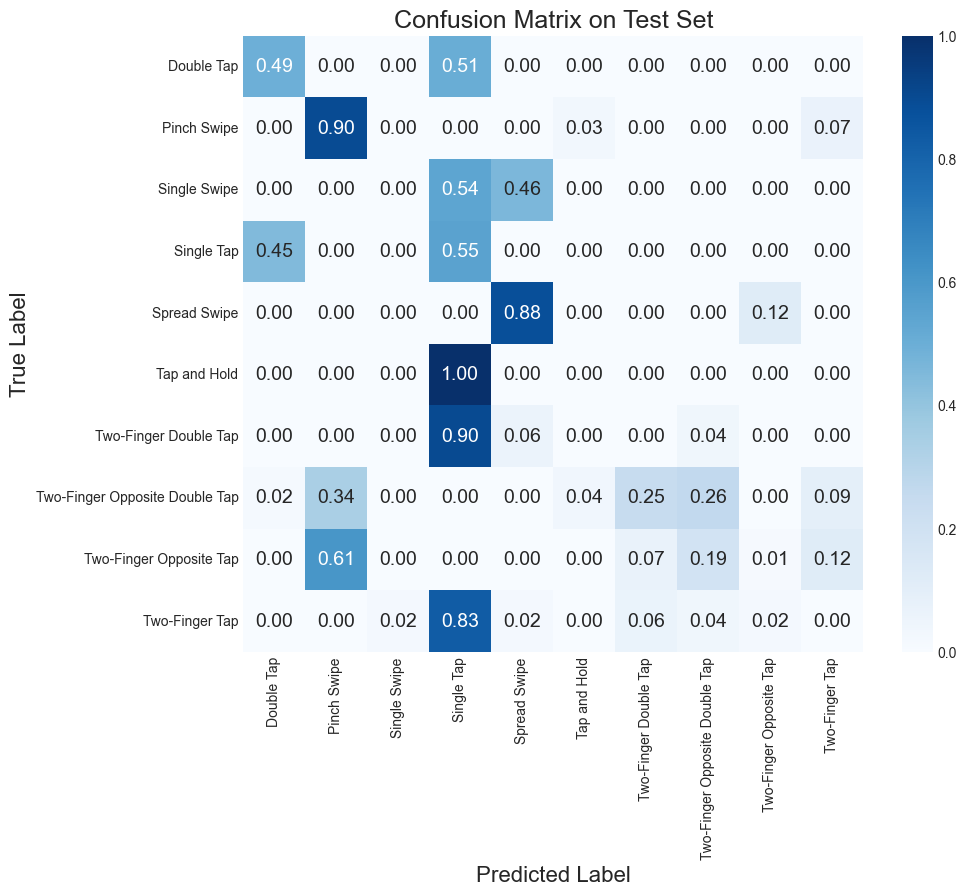

In [30]:
# Draw heatmap of confusion matrix for test set
from sklearn.metrics import confusion_matrix, classification_report

y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)
y_test_true = np.argmax(y_test, axis=1)

used_labels = np.unique(np.concatenate([y_test_pred, y_test_true]))
used_labels_names = le.inverse_transform(used_labels)
print(
    classification_report(
        y_test_true,
        y_test_pred,
    )
)

cm = confusion_matrix(y_test_true, y_test_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, annot_kws={"fontsize": 14})
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.title('Confusion Matrix on Test Set', fontsize=18)
plt.show()